In [23]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
%matplotlib inline


In [24]:
df = pd.read_csv("Algerian_forest_fires_dataset_cleaned.csv")


In [25]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [26]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [27]:
## drop month day and year
df.drop(["day","month","year"],axis = 1,inplace=True)

In [28]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [29]:
df["Classes"].value_counts()

Classes
fire             131
not fire         100
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [30]:
### Encoding
df["Classes"] = np.where(df["Classes"].str.contains("not fire"),0,1)

In [31]:
df["Classes"].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [32]:
## Independent and dependent Features
X = df.drop('FWI',axis= 1)
Y = df['FWI']


In [33]:
Y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [34]:
## TRain Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.25,random_state=42)


In [35]:
X_train.shape,X_test.shape

((181, 11), (61, 11))

In [36]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.650346,-0.302105,-0.329711,0.703237,0.494261,0.377424,0.617606,0.466352,0.525551,0.249598
RH,-0.650346,1.000000,0.266525,0.234932,-0.634330,-0.413931,-0.246125,-0.693939,-0.364136,-0.435094,-0.364007
Ws,-0.302105,0.266525,1.000000,0.219681,-0.171843,0.000277,0.105115,0.005360,0.038701,-0.059470,-0.235477
Rain,-0.329711,0.234932,0.219681,1.000000,-0.546501,-0.286855,-0.300276,-0.346706,-0.297934,-0.386323,-0.065132
FFMC,0.703237,-0.634330,-0.171843,-0.546501,1.000000,0.621240,0.537884,0.751558,0.610780,0.780805,0.222702
DMC,0.494261,-0.413931,0.000277,-0.286855,0.621240,1.000000,0.876734,0.693404,0.983698,0.613507,0.196778
DC,0.377424,-0.246125,0.105115,-0.300276,0.537884,0.876734,1.000000,0.548992,0.946992,0.546427,-0.081403
ISI,0.617606,-0.693939,0.005360,-0.346706,0.751558,0.693404,0.548992,1.000000,0.659589,0.749722,0.266275
BUI,0.466352,-0.364136,0.038701,-0.297934,0.610780,0.983698,0.946992,0.659589,1.000000,0.609708,0.096607
Classes,0.525551,-0.435094,-0.059470,-0.386323,0.780805,0.613507,0.546427,0.749722,0.609708,1.000000,0.161852


<Axes: >

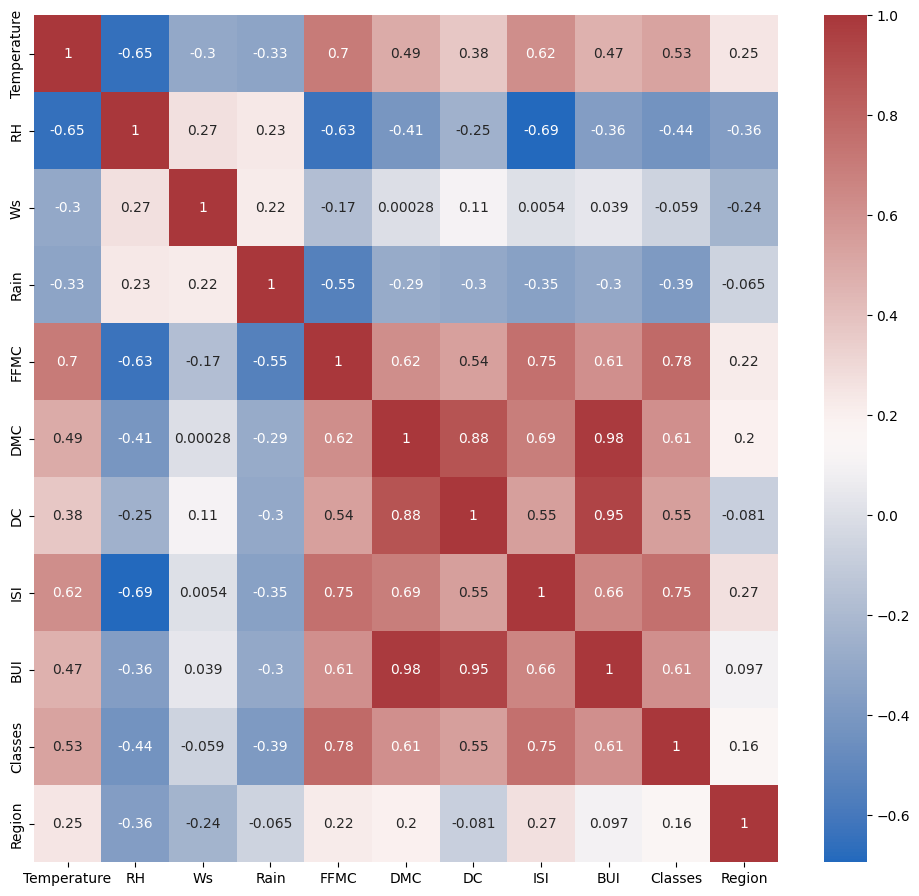

In [37]:
### Check for mutli collinearlity
plt.figure(figsize =(12,11))
corr = X_train.corr()
sns.heatmap(corr,annot=True,cmap ='vlag')

In [44]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr            

In [48]:
### threshold --Domain expertise
corr_features = correlation(X_train,0.85)

In [49]:
## drop features  when correlation is more than 0.85
X_train.drop(corr_features,axis =1 ,inplace = True)
X_test.drop(corr_features,axis =1,inplace =True)
X_train.shape,X_test.shape

((181, 9), (61, 9))

In [64]:
### Features Scalaing or Standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [65]:
x_train_scaled

array([[-0.82836812,  0.75305576,  1.27406033, ..., -0.60658617,
        -1.07459849, -0.98356052],
       [-0.02800533, -0.52331623, -0.52192814, ...,  0.08124507,
         0.93058013,  1.01671425],
       [-0.82836812, -1.46380085, -2.67711431, ..., -0.46427625,
         0.93058013,  1.01671425],
       ...,
       [-1.89551851,  0.88741071,  0.55566494, ..., -1.05723422,
        -1.07459849, -0.98356052],
       [ 1.03914506, -0.45613875,  0.19646725, ...,  0.84023126,
         0.93058013,  1.01671425],
       [-0.56158052,  0.95458818,  1.99245572, ..., -0.84376935,
        -1.07459849, -0.98356052]], shape=(181, 9))

Text(0.5, 1.0, 'X_train after Scaling')

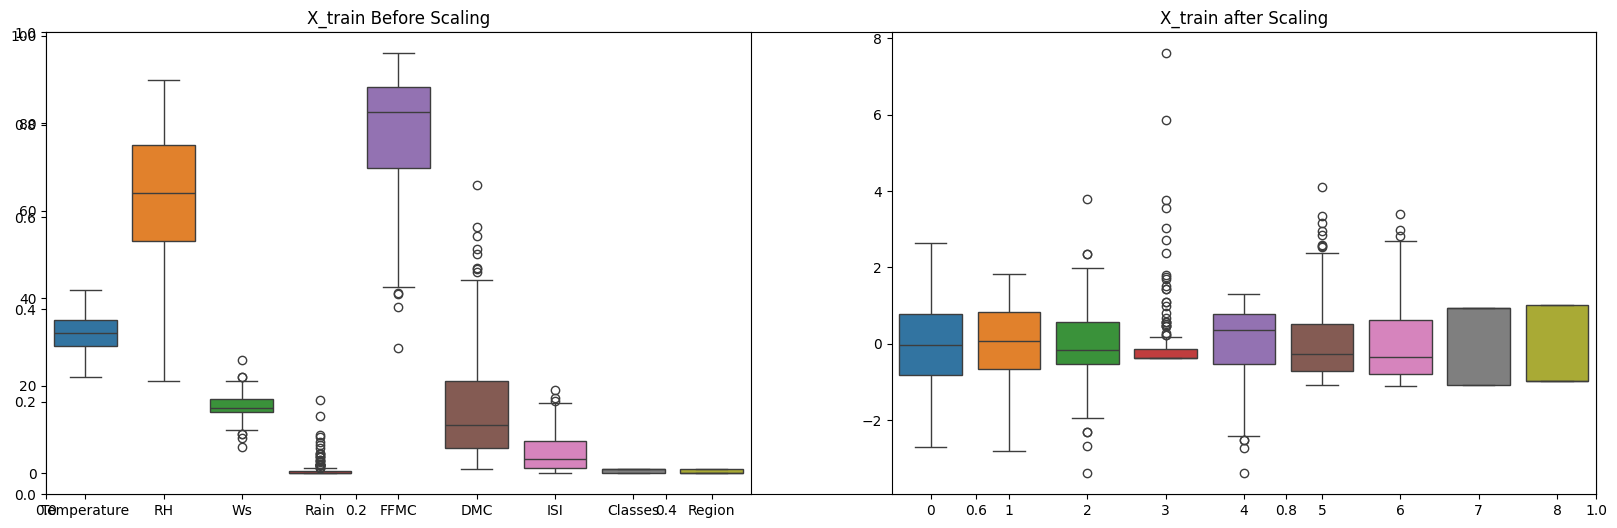

In [66]:
### box plot to understand teh effect of Standard Scaler
plt.subplots(figsize=(20,6))
plt.subplot(1,2,1)
sns.boxplot(data= X_train)
plt.title("X_train Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data = x_train_scaled)
plt.title('X_train after Scaling')


### Linear Regression Model

Mean Absolute Error: 0.5838063599546971
R² Score: 0.983523052949508


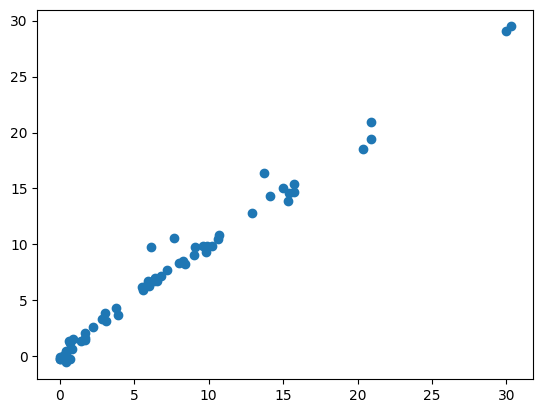

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Create Model
lr = LinearRegression()

# Train Model
lr.fit(x_train_scaled, Y_train)

# Predict on Scaled Test Data
y_pred = lr.predict(x_test_scaled)

# Evaluation
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test,y_pred)

Mean Absolute Error: 1.1459979969391694
R² Score: 0.9497712193501187


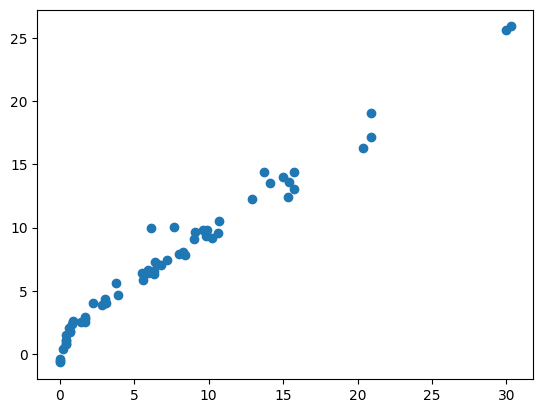

In [69]:
### Apply the Lasso Regression 

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

# Create Model
lasso= Lasso()

# Train Model
lasso.fit(x_train_scaled, Y_train)

# Predict on Scaled Test Data
y_pred = lasso.predict(x_test_scaled)

# Evaluation
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)

Mean Absolute Error: 0.612551563810103
R² Score: 0.9826983552292979


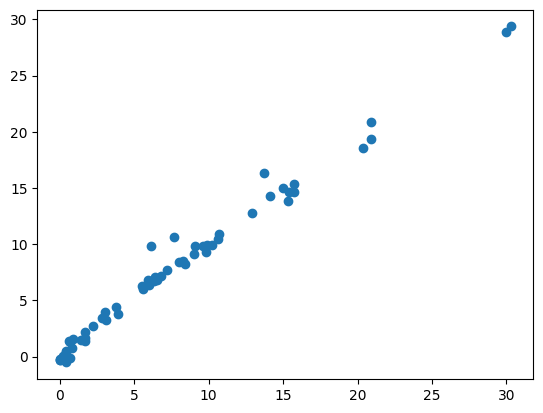

In [70]:
## Ridge Regression model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# Create Model
ri = Ridge()

# Train Model
ri.fit(x_train_scaled, Y_train)

# Predict on Scaled Test Data
y_pred = ri.predict(x_test_scaled)

# Evaluation
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)

Mean Absolute Error: 1.8915134363047037
R² Score: 0.8731354681001338


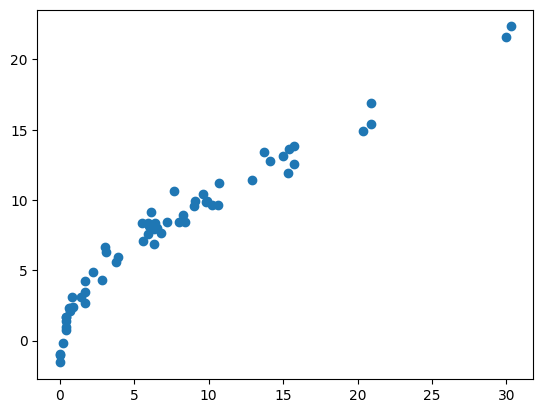

In [71]:
### Elastic Net Regression 
# Ridge Regression model
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

# Create Model
en = ElasticNet()

# Train Model
en.fit(x_train_scaled, Y_train)

# Predict on Scaled Test Data
y_pred = en.predict(x_test_scaled)

# Evaluation
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)

In [72]:
## Cross Validation Lasso
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(x_train_scaled,Y_train)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [73]:
lassocv.predict(x_test_scaled)

array([ 8.19997214,  7.66623541,  7.02538398,  6.44211723,  6.88679949,
       10.44864571, 10.75158518,  2.98251618,  1.95391663,  3.43809805,
        0.71100452, 10.0376891 ,  9.39363065, 28.63386619, 18.25088477,
        1.04069653,  4.77485635, -0.83606004,  7.31055552,  6.14289033,
        1.96691115,  0.12444081,  6.47048742,  0.11648953, 20.81752937,
       14.29654246,  5.91349113,  9.78479493, -0.97207988, 14.94139715,
        6.80427509, -0.33558816, 10.34599981, 14.47347145,  1.71462483,
        3.19844054,  2.11673692,  6.08596815, -0.10794757, -0.46646502,
        6.51304649,  2.03687769,  8.46191428, -0.99900332, 15.34094276,
        8.37293083,  9.9032421 ,  1.3951187 ,  0.27181728,  1.21868371,
       29.03138927,  3.74933891, 12.90104549, 19.2406655 , 13.66915148,
       16.1737583 ,  9.90052436,  9.15474301,  3.95099252, 14.42821423,
        9.97049434])

In [74]:
lassocv.alpha_

np.float64(0.06949475329820431)

In [76]:
lassocv.alphas_

array([6.94947533, 6.48110395, 6.04429924, 5.6369337 , 5.25702323,
       4.90271746, 4.57229071, 4.26413362, 3.97674529, 3.70872596,
       3.45877025, 3.22566071, 3.00826197, 2.80551518, 2.61643285,
       2.44009403, 2.27563986, 2.12226935, 1.9792355 , 1.84584165,
       1.7214381 , 1.60541894, 1.49721907, 1.39631152, 1.3022048 ,
       1.21444055, 1.13259132, 1.05625846, 0.98507017, 0.91867974,
       0.8567638 , 0.79902079, 0.74516946, 0.69494753, 0.6481104 ,
       0.60442992, 0.56369337, 0.52570232, 0.49027175, 0.45722907,
       0.42641336, 0.39767453, 0.3708726 , 0.34587702, 0.32256607,
       0.3008262 , 0.28055152, 0.26164329, 0.2440094 , 0.22756399,
       0.21222694, 0.19792355, 0.18458417, 0.17214381, 0.16054189,
       0.14972191, 0.13963115, 0.13022048, 0.12144406, 0.11325913,
       0.10562585, 0.09850702, 0.09186797, 0.08567638, 0.07990208,
       0.07451695, 0.06949475, 0.06481104, 0.06044299, 0.05636934,
       0.05257023, 0.04902717, 0.04572291, 0.04264134, 0.03976

In [77]:
lassocv.mse_path_

array([[54.96561328, 59.15785653, 38.72729712, 78.24916791, 53.00661707],
       [48.33127341, 52.98238939, 33.40705056, 76.17370919, 47.37592787],
       [42.489492  , 46.9476325 , 28.61641869, 69.11179183, 42.46600092],
       [37.38816074, 41.6222327 , 24.54198449, 62.88571919, 38.18380814],
       [32.93231013, 36.95463498, 21.08421335, 57.39228141, 33.53847098],
       [29.03908563, 32.86149181, 18.15701813, 52.54133041, 29.14966015],
       [25.63631212, 29.27011099, 15.68586523, 48.25410422, 25.34331445],
       [22.66140204, 26.11749884, 13.60632992, 43.16468118, 22.0425561 ],
       [20.05957707, 23.34834079, 11.86266757, 37.9874641 , 19.18168383],
       [17.78321296, 20.91452315, 10.40680285, 33.46741145, 16.70233718],
       [15.79082322, 18.77407566,  9.19714128, 29.52048402, 14.5542223 ],
       [14.0461701 , 16.89025254,  8.19780164, 26.07233474, 12.69363691],
       [12.51796119, 15.23137028,  7.37783328, 23.06047803, 11.08260866],
       [11.17864417, 13.76938633,  6.7

Mean Absolute Error: 0.6792732015276415
R² Score: 0.9805435134269989


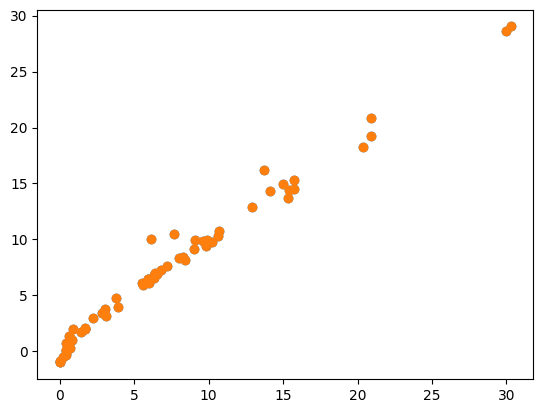

In [80]:
y_pred = lassocv.predict(x_test_scaled)
plt.scatter(Y_test,y_pred)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)

Mean Absolute Error: 0.8566908888843284
R² Score: 0.9729928114396738


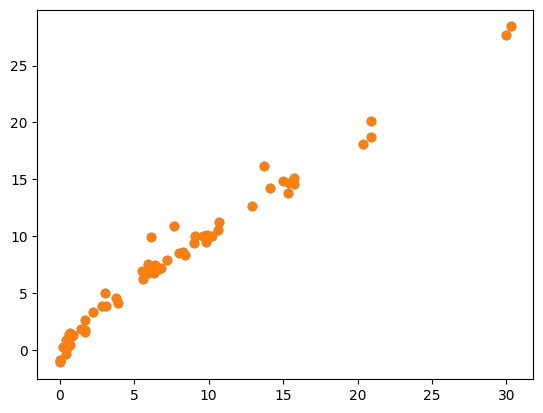

In [81]:
from sklearn.linear_model import RidgeCV
ridgeCv = RidgeCV(cv = 5)## if cv = None it gonna sue leaf out cv
ridgeCv.fit(x_train_scaled,Y_train)
y_pred = ridgeCv.predict(x_test_scaled)
plt.scatter(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)

In [82]:
ridgeCv.alphas

(0.1, 1.0, 10.0)

In [84]:
ridgeCv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

Mean Absolute Error: 0.7295307419548663
R² Score: 0.9789324233433637


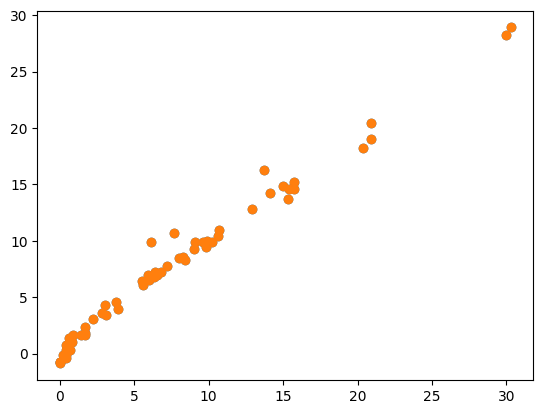

In [85]:
from sklearn.linear_model import ElasticNetCV
ev = ElasticNetCV(cv=5)  # if cv = None it gonna sue leaf out cv
ev.fit(x_train_scaled, Y_train)
y_pred = ev.predict(x_test_scaled)
plt.scatter(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
plt.scatter(Y_test, y_pred)